## Wearable Tech: Week 4 Assignment

### Step 1

In [27]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates
import datetime
import plotly.graph_objects as go

import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 4 - Wearable Technologies and Sports Analytics/Week 4 Content/FH.csv", index_col =["Timestamp"], parse_dates=["Timestamp"])

In [29]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

### Step 2

In [30]:
# Create a slice of the dataframe to use for this assessment based on the date of the game: August 19, 2018
Game_08_19_df = df.loc['2018-08-19']
Game_08_19_df.shape

(1781613, 9)

### Step 3

In [31]:
# Determine the total number of HR data points that were recorded with a value of zero and note the total number of rows in the dataset for the date you have selected (August 19)
(Game_08_19_df == 0).sum(axis=0)

,0
Seconds,21
Velocity,877907
Acceleration,7333
Odometer,4346
Latitude,0
Longitude,0
Heart Rate,463914
Player Load,2911
AthleteID,0


### Step 4

In [32]:
%%capture
Game_08_19_df.loc[Game_08_19_df['Heart Rate'] ==0,'Heart Rate'] = np.nan

In [33]:
# Determine the % of the missing HR data for each individual athlete and keep only the athletes that have less than 10% of their HR data missing for the remainder of this assignment.
DataCount = Game_08_19_df.groupby('AthleteID')[['Heart Rate','Player Load']].count()

DataCount['Missing HR values']= (DataCount['Player Load']-DataCount['Heart Rate'])
DataCount['% HR missing'] = DataCount['Missing HR values']/DataCount['Player Load']*100

print(DataCount)

            Heart Rate  Player Load  Missing HR values  % HR missing
AthleteID                                                           
Athlete 1        58139        74809              16670     22.283415
Athlete 10       86464        86497                 33      0.038152
Athlete 11       47363        84080              36717     43.669125
Athlete 12       86340        86347                  7      0.008107
Athlete 13       85287        85805                518      0.603694
Athlete 15       84766        84980                214      0.251824
Athlete 17       41628        85124              43496     51.097223
Athlete 18       76845        86385               9540     11.043584
Athlete 19       86065        86301                236      0.273461
Athlete 2         8241        85688              77447     90.382551
Athlete 20       81299        85378               4079      4.777577
Athlete 21       48032        85135              37103     43.581371
Athlete 22       49481        8412

In [34]:
Game_08_19_df=Game_08_19_df[Game_08_19_df['AthleteID'].isin(DataCount.query("`% HR missing` < 10").index)]
Game_08_19_df.shape

(854463, 9)

### Step 5

In [35]:
# Calculate the playerload “delta” (player load change) and be sure you eliminate any negative PLdelta scores.
Game_08_19_df['PLdelta'] = Game_08_19_df['Player Load'].diff().fillna(0)

In [36]:
Game_08_19_df.loc[Game_08_19_df['PLdelta'] <0,'PLdelta'] = np.nan

### Step 6

In [37]:
# Determine the correlation between the Heart Rate and the rolling playerload change value over 30, 60 and 90 seconds and note the pearson correlation “r” value for this date.
Game_08_19_df['PLd_rolling_30sec'] = Game_08_19_df['PLdelta'].rolling(300).sum()
Game_08_19_df['PLd_rolling_60sec'] = Game_08_19_df['PLdelta'].rolling(600).sum()
Game_08_19_df['PLd_rolling_90sec'] = Game_08_19_df['PLdelta'].rolling(900).sum()

Game_08_19_df.corr(numeric_only=True, method='pearson')

,Seconds,Velocity,Acceleration,Odometer,Latitude,Longitude,Heart Rate,Player Load,PLdelta,PLd_rolling_30sec,PLd_rolling_60sec,PLd_rolling_90sec
Seconds,1.000000,-0.009364,-0.000568,0.857687,0.033476,-0.011728,0.001798,0.882878,-0.011311,-0.036991,-0.041210,-0.044762
Velocity,-0.009364,1.000000,0.137047,0.086850,-0.010985,0.514456,0.521209,0.076898,0.420413,0.677419,0.637155,0.609472
Acceleration,-0.000568,0.137047,1.000000,-0.001708,-0.002507,0.001218,-0.015080,-0.001803,0.070592,-0.062629,-0.036997,-0.028615
Odometer,0.857687,0.086850,-0.001708,1.000000,0.029656,0.094239,0.188131,0.991606,0.023749,0.078801,0.090109,0.097611
Latitude,0.033476,-0.010985,-0.002507,0.029656,1.000000,0.298364,0.085743,0.035070,0.016297,0.040721,0.033087,0.017567
Longitude,-0.011728,0.514456,0.001218,0.094239,0.298364,1.000000,0.640690,0.082396,0.207534,0.625605,0.649042,0.656403
Heart Rate,0.001798,0.521209,-0.015080,0.188131,0.085743,0.640690,1.000000,0.170010,0.203019,0.686249,0.734770,0.742744
Player Load,0.882878,0.076898,-0.001803,0.991606,0.035070,0.082396,0.170010,1.000000,0.022002,0.073446,0.084151,0.091226
PLdelta,-0.011311,0.420413,0.070592,0.023749,0.016297,0.207534,0.203019,0.022002,1.000000,0.280752,0.258215,0.244698
PLd_rolling_30sec,-0.036991,0.677419,-0.062629,0.078801,0.040721,0.625605,0.686249,0.073446,0.280752,1.000000,0.915021,0.855634


### Step 7

,0
AthleteID,
Athlete 10,"Axes(0.125,0.11;0.62x0.77)"
Athlete 12,"Axes(0.125,0.11;0.62x0.77)"
Athlete 13,"Axes(0.125,0.11;0.62x0.77)"
Athlete 15,"Axes(0.125,0.11;0.62x0.77)"
Athlete 19,"Axes(0.125,0.11;0.62x0.77)"
Athlete 20,"Axes(0.125,0.11;0.62x0.77)"
Athlete 24,"Axes(0.125,0.11;0.62x0.77)"
Athlete 3,"Axes(0.125,0.11;0.62x0.77)"
Athlete 6,"Axes(0.125,0.11;0.62x0.77)"


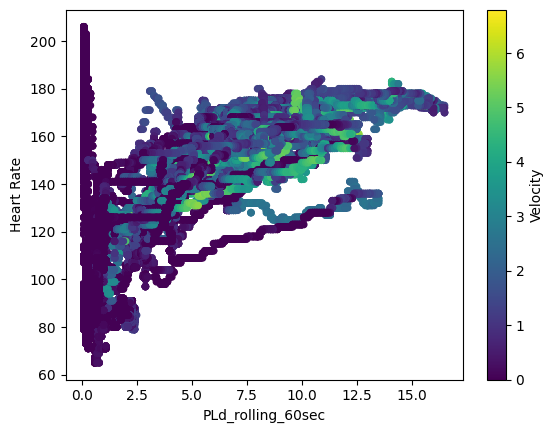

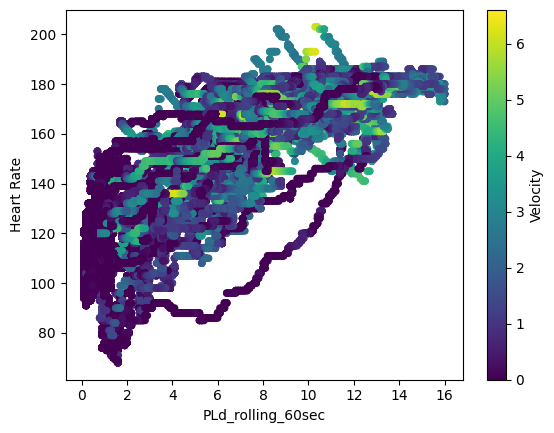

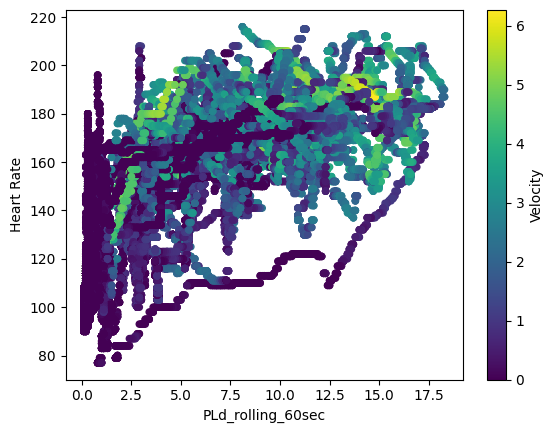

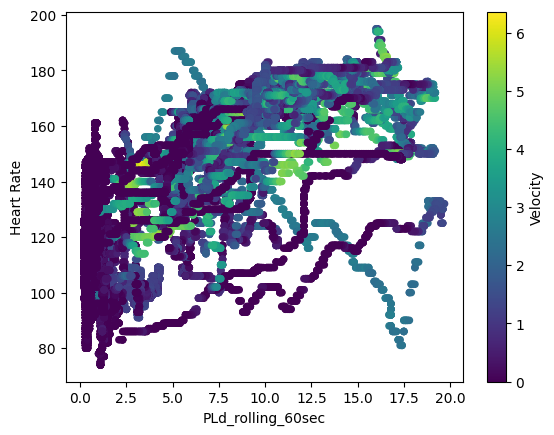

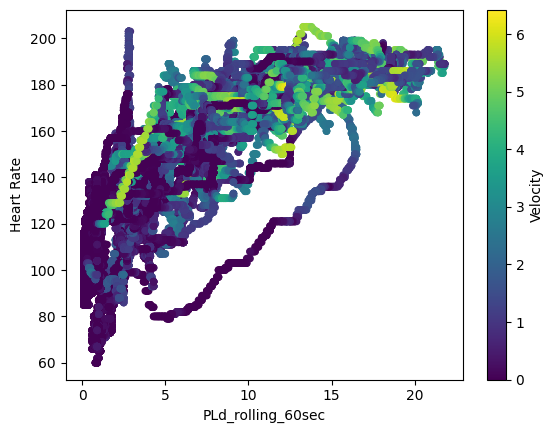

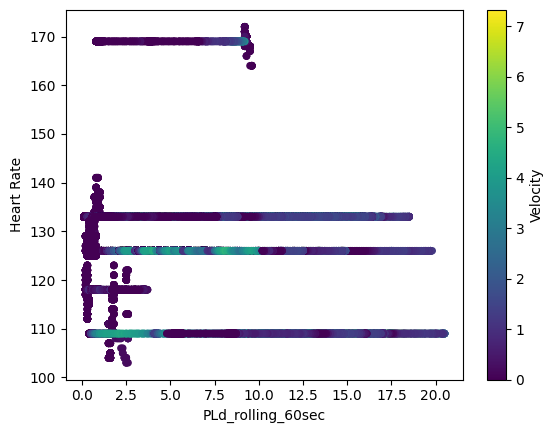

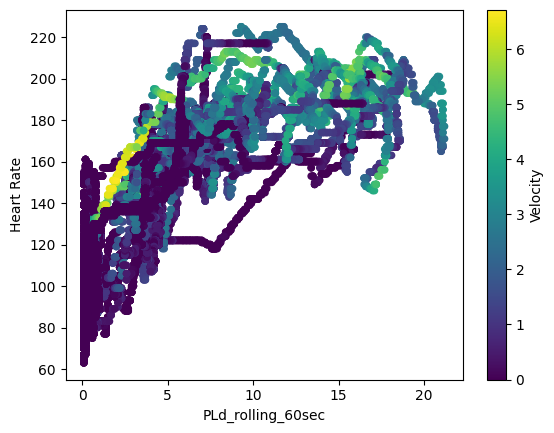

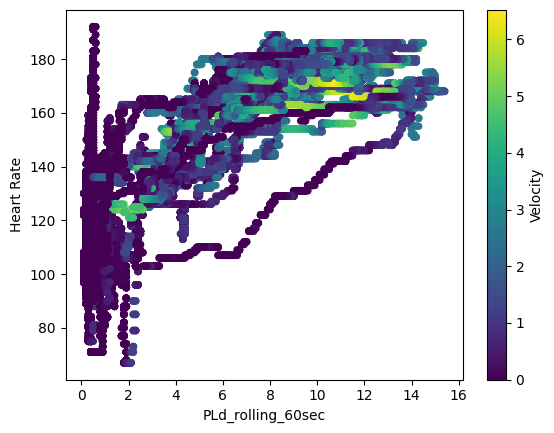

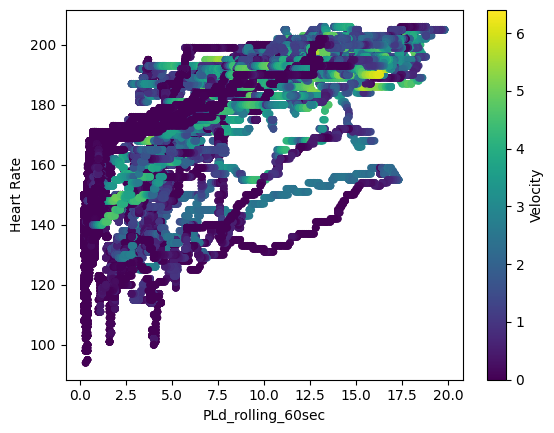

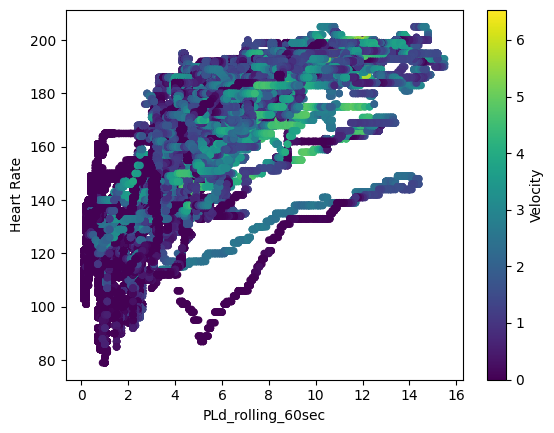

In [38]:
# Use the groupby, plot.scatter method to calculate the relationship between the rolling playerload change over 60 seconds versus the heart rate values.
# Note which of the graphs looks especially peculiar.
Game_08_19_df.groupby('AthleteID').plot.scatter(x='PLd_rolling_60sec', y='Heart Rate', c="Velocity", colormap='viridis')

Athlete 20's graph looks peculiar as instead of the form all the other graphs take it is just a few horizontal lines.

### Step 8

In [39]:
Game_08_19_df.dropna(inplace=True)

In [40]:
Game_08_19_df.isnull().values.any()

np.False_

In [41]:
# Determine the slope and y-intercept for (only) the athletes that had good data on both days.  There should be 6 in total.
# Compare and contrast the values between the two days.  Identify the top 2 players on both days.
Ath13_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 13']
Ath15_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 15']
Ath19_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 19']
Ath24_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 24']
Ath3_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 3']
Ath6_Game_08_19_df=Game_08_19_df.loc[Game_08_19_df['AthleteID'] == 'Athlete 6']

Athlete 13 LinregressResult(slope=np.float64(5.249742795811485), intercept=np.float64(118.28170113625399), rvalue=np.float64(0.7927842434817515), pvalue=np.float64(0.0), stderr=np.float64(0.01389395186813833), intercept_stderr=np.float64(0.07956132085945643))


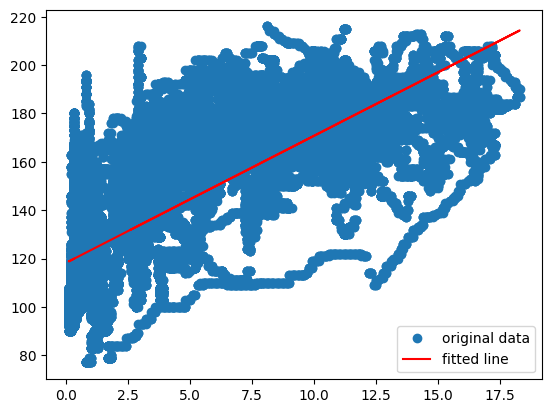

            0
0  Athlete 13
1    5.249743
2  118.281701


In [42]:
# Athlete 13
x = np.array(Ath13_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath13_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 13", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes13 = pd.DataFrame(['Athlete 13', res.slope, res.intercept])
print(slopes13)

Athlete 15 LinregressResult(slope=np.float64(4.3398268113028395), intercept=np.float64(111.88094649001766), rvalue=np.float64(0.7975869253896785), pvalue=np.float64(0.0), stderr=np.float64(0.011333609057671843), intercept_stderr=np.float64(0.06938512178469311))


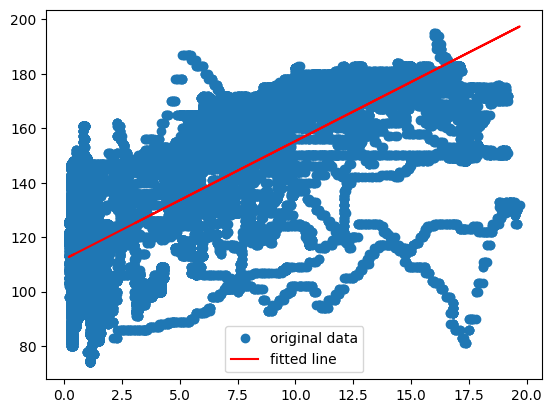

            0
0  Athlete 15
1    4.339827
2  111.880946


In [43]:
# Athlete 15
x = np.array(Ath15_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath15_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 15", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes15 = pd.DataFrame(['Athlete 15', res.slope, res.intercept])
print(slopes15)

Athlete 19 LinregressResult(slope=np.float64(5.393069012776207), intercept=np.float64(109.1838778306753), rvalue=np.float64(0.8900501891613203), pvalue=np.float64(0.0), stderr=np.float64(0.009464869243285528), intercept_stderr=np.float64(0.07279434823074747))


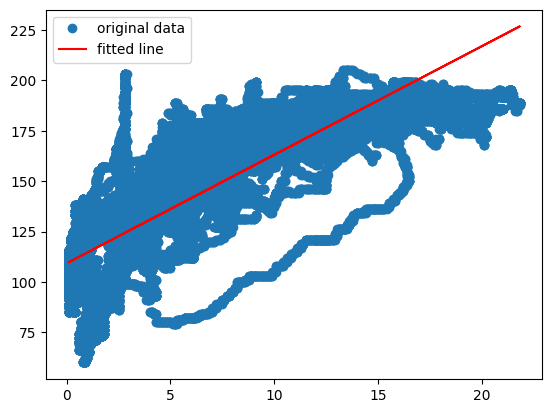

In [44]:
# Athlete 19
x = np.array(Ath19_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath19_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 19", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes19 = pd.DataFrame(['Athlete 19', res.slope, res.intercept])

Athlete 24 LinregressResult(slope=np.float64(7.27047211282448), intercept=np.float64(100.55583141635434), rvalue=np.float64(0.8378412589221045), pvalue=np.float64(0.0), stderr=np.float64(0.01639643523540907), intercept_stderr=np.float64(0.07648438317951547))


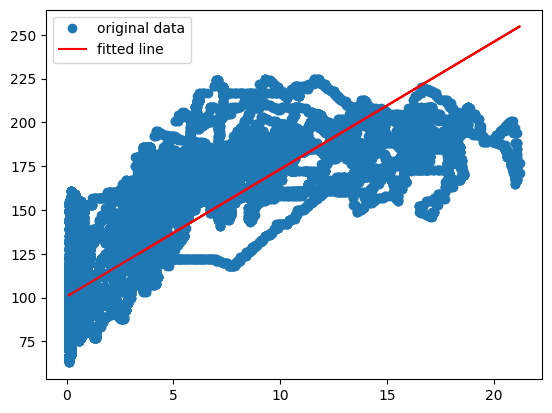

In [45]:
# Athlete 24
x = np.array(Ath24_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath24_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 24", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes24 = pd.DataFrame(['Athlete 24', res.slope, res.intercept])

Athlete 3 LinregressResult(slope=np.float64(5.538835458995807), intercept=np.float64(118.2457590629314), rvalue=np.float64(0.8394980636463757), pvalue=np.float64(0.0), stderr=np.float64(0.012503345920178295), intercept_stderr=np.float64(0.06729153343136332))


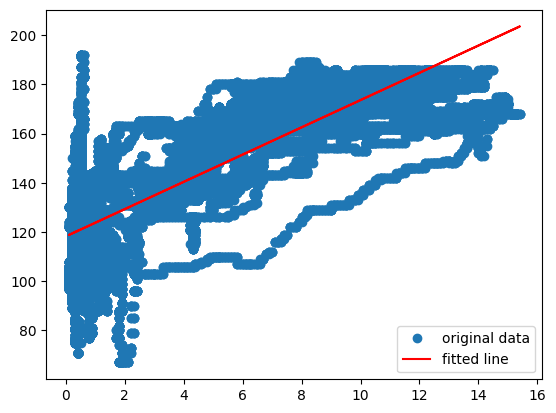

In [46]:
# Athlete 3
x = np.array(Ath3_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath3_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 3", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes3 = pd.DataFrame(['Athlete 3', res.slope, res.intercept])

Athlete 6 LinregressResult(slope=np.float64(3.816962865593923), intercept=np.float64(143.3116401660895), rvalue=np.float64(0.8393416741917128), pvalue=np.float64(0.0), stderr=np.float64(0.008534760613985845), intercept_stderr=np.float64(0.07490970916460717))


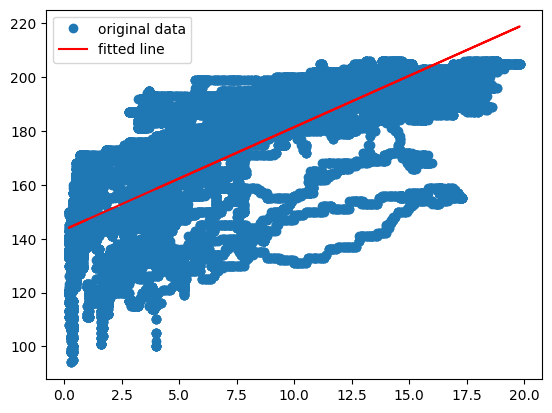

In [47]:
# Athlete 6
x = np.array(Ath6_Game_08_19_df['PLd_rolling_60sec'])
y = np.array(Ath6_Game_08_19_df['Heart Rate'])

res = stats.linregress(x, y)

print("Athlete 6", res)
plt.plot(x, y, 'o', label='original data')
plt.plot(x, res.intercept + res.slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

slopes6 = pd.DataFrame(['Athlete 6', res.slope, res.intercept])

In [48]:
slope_df=pd.concat([slopes13, slopes15, slopes19, slopes24, slopes3, slopes6], axis=1)
slope_df

,0,0,0,0,0,0
0,Athlete 13,Athlete 15,Athlete 19,Athlete 24,Athlete 3,Athlete 6
1,5.249743,4.339827,5.393069,7.270472,5.538835,3.816963
2,118.281701,111.880946,109.183878,100.555831,118.245759,143.31164


In [49]:
slope_df=slope_df.T
print(slope_df.columns)

RangeIndex(start=0, stop=3, step=1)


In [50]:
slope_df.reset_index()

,index,0,1,2
0,0,Athlete 13,5.249743,118.281701
1,0,Athlete 15,4.339827,111.880946
2,0,Athlete 19,5.393069,109.183878
3,0,Athlete 24,7.270472,100.555831
4,0,Athlete 3,5.538835,118.245759
5,0,Athlete 6,3.816963,143.31164


In [51]:
# Final Table
slope_df.columns= ['Athlete #', 'Slope', 'Intercept']
slope_df

,Athlete #,Slope,Intercept
0,Athlete 13,5.249743,118.281701
0,Athlete 15,4.339827,111.880946
0,Athlete 19,5.393069,109.183878
0,Athlete 24,7.270472,100.555831
0,Athlete 3,5.538835,118.245759
0,Athlete 6,3.816963,143.31164


Top 2 players on this day are athletes 3 and 24, and the top 2 athletes from the last day workbook are athletes 3 and 13.

In [52]:
slope_df['BPM150']=(150-slope_df['Intercept'])/slope_df['Slope']
slope_df

,Athlete #,Slope,Intercept,BPM150
0,Athlete 13,5.249743,118.281701,6.041877
0,Athlete 15,4.339827,111.880946,8.783543
0,Athlete 19,5.393069,109.183878,7.568255
0,Athlete 24,7.270472,100.555831,6.800682
0,Athlete 3,5.538835,118.245759,5.733018
0,Athlete 6,3.816963,143.31164,1.752273


In [53]:
slope_df['BPM180']=(180-slope_df['Intercept'])/slope_df['Slope']
slope_df

,Athlete #,Slope,Intercept,BPM150,BPM180
0,Athlete 13,5.249743,118.281701,6.041877,11.756442
0,Athlete 15,4.339827,111.880946,8.783543,15.696261
0,Athlete 19,5.393069,109.183878,7.568255,13.13095
0,Athlete 24,7.270472,100.555831,6.800682,10.926961
0,Athlete 3,5.538835,118.245759,5.733018,11.149319
0,Athlete 6,3.816963,143.31164,1.752273,9.611925


Athletes 15 and 19 have the highest capacity at 150BPM and 180BPM on this day and on the previous day workbook athletes 15, 18, and 19 have the highest capacity at 150BPM and 180BPM.